Environment Setup

In [40]:
import os
import yaml
import fiftyone as fo
import fiftyone.zoo as foz
from pathlib import Path

Data Loading

In [41]:
# 1. Define absolute paths to avoid confusion
# We go up one level from 'notebooks' to get to the project root
ROOT_DIR = Path(os.getcwd()).parent 
DATASET_DIR = ROOT_DIR / "data" / "processed" / "yolo_dataset"
YAML_PATH = DATASET_DIR / "data.yaml"

# 2. Verify paths exist
if not YAML_PATH.exists():
    raise FileNotFoundError(f"Could not find data.yaml at {YAML_PATH}")

# 3. Load the dataset into FiftyOne
# We explicitly tell FiftyOne where the images and labels are for the 'val' split
dataset_name = "Weapon_Detection_EDA"

# Delete existing dataset if it exists to start fresh
if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)

dataset = fo.Dataset.from_dir(
    dataset_dir=str(DATASET_DIR),
    dataset_type=fo.types.YOLOv5Dataset,
    overwrite=True,
    yaml_path=str(YAML_PATH),
    name=dataset_name,
    split="test" 
)

print(f"Total samples loaded: {len(dataset)}")
print(f"Classes found: {dataset.default_classes}")


 100% |███████████████| 4126/4126 [5.6s elapsed, 0s remaining, 578.1 samples/s]      
Total samples loaded: 4126
Classes found: []


Class Distribution Analysis

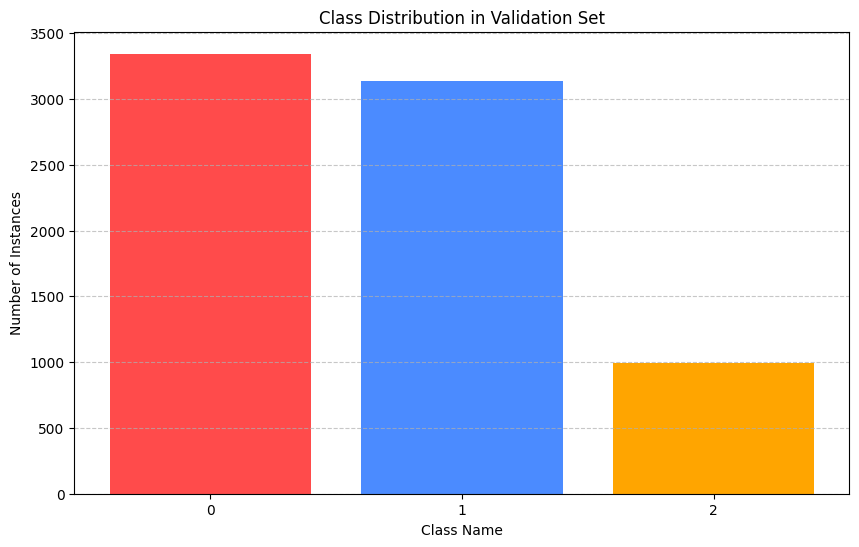

 0: 3344 instances
 1: 3139 instances
 2: 991 instances


In [42]:
# Calculate class counts
counts = dataset.count_values("ground_truth.detections.label")

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values(), color=['#FF4B4B', '#4B8BFF', '#FFA500'])
plt.title("Class Distribution in Validation Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Instances")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for label, count in counts.items():
    print(f" {label}: {count} instances")
